# Random Forest Classifier for Customer Churn Prediction

## Objective

The objective of this notebook is to develop a Random Forest classifier for predicting customer churn and compare its performance with the previously developed Logistic Regression and Decision Tree models.

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees using bootstrap sampling and random feature selection.

Compared with a single Decision Tree, Random Forest generally:

- Reduces overfitting
- Improves generalization
- Produces more stable predictions
- Provides robust feature importance estimates

This notebook includes:

- Baseline Random Forest
- Cross Validation
- Hyperparameter Tuning
- Feature Importance
- Model Comparison
- Model Serialization

In [2]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn import set_config

set_config(display="diagram")

## Load Feature Engineered Dataset

The feature engineered dataset generated in Notebook 03 is used for training the Random Forest model.

Using the same dataset ensures a fair comparison with the previously developed models.

In [3]:
df = pd.read_csv("../data/processed/telco_feature_engineered.csv")

In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (7032, 27)
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-

## Define Features and Target

The customer identifier and target columns are removed from the feature matrix.

The binary churn indicator is used as the prediction target.

In [5]:
X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_Binary"
    ]
)

y = df["Churn_Binary"]

print("Feature Matrix :", X.shape)
print("Target Vector  :", y.shape)

Feature Matrix : (7032, 24)
Target Vector  : (7032,)


In [6]:
continuous_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "TotalServices"
]

binary_features = [
    "SeniorCitizen",
    "HasFamily"
]

nominal_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

ordinal_features = [
    "TenureGroup",
    "SpendingGroup"
]

In [7]:
print("Continuous Features")
print(continuous_features)

print()

print("Binary Features")
print(binary_features)

print()

print("Nominal Features")
print(nominal_features)

print()

print("Ordinal Features")
print(ordinal_features)

Continuous Features
['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'TotalServices']

Binary Features
['SeniorCitizen', 'HasFamily']

Nominal Features
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Ordinal Features
['TenureGroup', 'SpendingGroup']


## Train-Test Split

The dataset is divided into training and testing subsets using stratified sampling.

Stratification preserves the class distribution in both subsets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (5625, 24)
Testing Samples : (1407, 24)


## Build Preprocessing Pipeline

Random Forest is based on Decision Trees.

Decision Trees do not require feature scaling because they split data using thresholds rather than distances.

Therefore:

- Continuous Features → Passthrough
- Binary Features → Passthrough
- Nominal Features → OneHotEncoder
- Ordinal Features → OrdinalEncoder

In [9]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            "continuous",
            "passthrough",
            continuous_features
        ),

        (
            "binary",
            "passthrough",
            binary_features
        ),

        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_features
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["New","Growing","Established","Loyal"],
                    ["Low","Medium","High"]
                ]
            ),
            ordinal_features
        )
    ]
)

## Baseline Random Forest

A baseline Random Forest classifier is trained using the default Scikit-Learn hyperparameters.

This provides a reference before hyperparameter tuning.

In [10]:
baseline_model = RandomForestClassifier(
    random_state=42
)

In [11]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", baseline_model)
    ]
)

In [12]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: floa

In [13]:
pipeline.fit(
    X_train,
    y_train
)

print("Baseline Random Forest trained successfully.")

Baseline Random Forest trained successfully.


In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [15]:
metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

cv_results = {}

for metric in metrics:

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=metric,
        n_jobs=-1
    )

    cv_results[metric] = scores

In [16]:
cv_summary = pd.DataFrame({
    "Metric": metrics,
    "Mean": [cv_results[m].mean() for m in metrics],
    "Std": [cv_results[m].std() for m in metrics]
})

cv_summary["Metric"] = cv_summary["Metric"].str.upper()

cv_summary = cv_summary.round(4)

cv_summary

,Metric,Mean,Std
0,ACCURACY,0.7924,0.0053
1,PRECISION,0.6422,0.0145
2,RECALL,0.4950,0.0244
3,F1,0.5586,0.0163
4,ROC_AUC,0.8287,0.0065


## Diagnose Overfitting

Training and testing accuracy are compared to determine whether the Random Forest model is overfitting.

A small difference between training and testing accuracy indicates good generalization.

In [17]:
train_pred = pipeline.predict(X_train)

test_pred = pipeline.predict(X_test)

comparison = pd.DataFrame({
    "Dataset":[
        "Training",
        "Testing"
    ],
    "Accuracy":[
        accuracy_score(y_train,train_pred),
        accuracy_score(y_test,test_pred)
    ]
})

comparison

,Dataset,Accuracy
0,Training,0.998756
1,Testing,0.784648


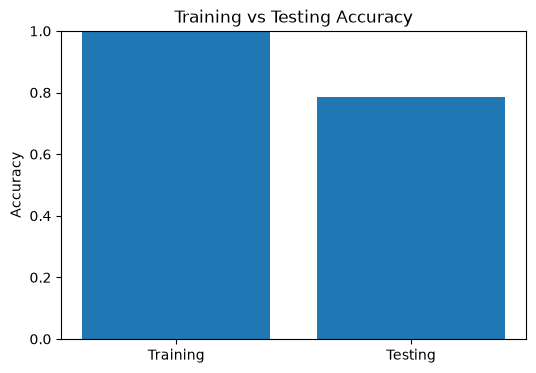

In [18]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Dataset"],
    comparison["Accuracy"]
)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Training vs Testing Accuracy")

plt.show()

## Hyperparameter Tuning

GridSearchCV is used to identify the optimal Random Forest hyperparameters.

The model is optimized using ROC-AUC.

In [19]:
param_grid = {

    "classifier__n_estimators":[
        100,
        200,
        300
    ],

    "classifier__max_depth":[
        5,
        10,
        20,
        None
    ],

    "classifier__min_samples_split":[
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf":[
        1,
        2,
        4
    ],

    "classifier__max_features":[
        "sqrt",
        "log2"
    ]
}

In [20]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [21]:
grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... v

In [22]:
print("Best Parameters")

print(grid_search.best_params_)

print()

print("Best ROC-AUC")

print(grid_search.best_score_)

Best Parameters
{'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}

Best ROC-AUC
0.8457724294865047


## Best Random Forest Model

The tuned Random Forest model obtained from GridSearchCV is used for final evaluation on the unseen test dataset.

Using the best estimator ensures that all selected hyperparameters are applied consistently.

In [23]:
best_pipeline = grid_search.best_estimator_

## Predictions

Predictions and class probabilities are generated using the tuned Random Forest model.

In [24]:
y_pred = best_pipeline.predict(X_test)

y_prob = best_pipeline.predict_proba(X_test)[:, 1]

## Model Evaluation

The tuned Random Forest model is evaluated using Accuracy, Precision, Recall, F1-Score and ROC-AUC.

In [25]:
test_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

test_summary = pd.DataFrame(
    test_results.items(),
    columns=["Metric", "Score"]
)

test_summary["Score"] = test_summary["Score"].round(4)

test_summary

,Metric,Score
0,Accuracy,0.7932
1,Precision,0.6436
2,Recall,0.4973
3,F1-Score,0.5611
4,ROC-AUC,0.8340


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



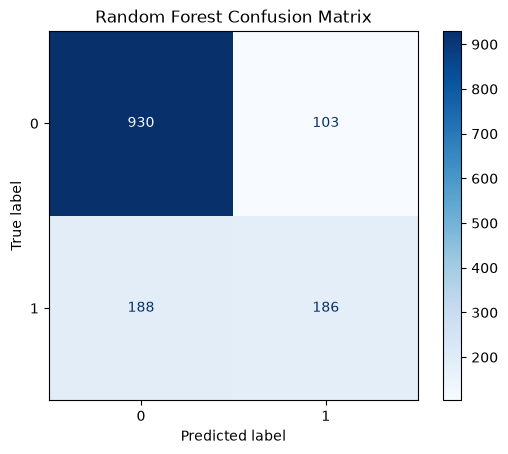

In [27]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

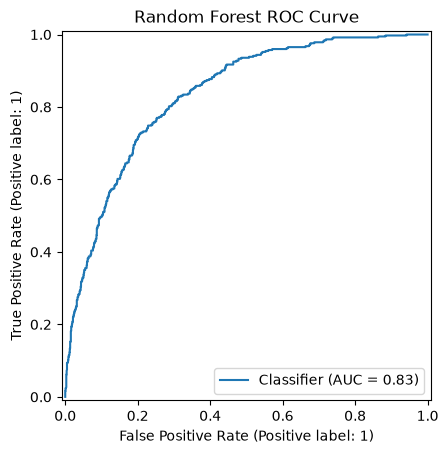

In [28]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Random Forest ROC Curve")

plt.show()

In [29]:
feature_names = best_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_pipeline.named_steps[
        "classifier"
    ].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
0,continuous__tenure,0.119196
2,continuous__TotalCharges,0.096120
39,nominal__Contract_Month-to-month,0.090010
1,continuous__MonthlyCharges,0.063783
3,continuous__AvgMonthlySpend,0.060305
48,ordinal__TenureGroup,0.057659
21,nominal__OnlineSecurity_No,0.048198
30,nominal__TechSupport_No,0.038659
19,nominal__InternetService_Fiber optic,0.038125
41,nominal__Contract_Two year,0.035827


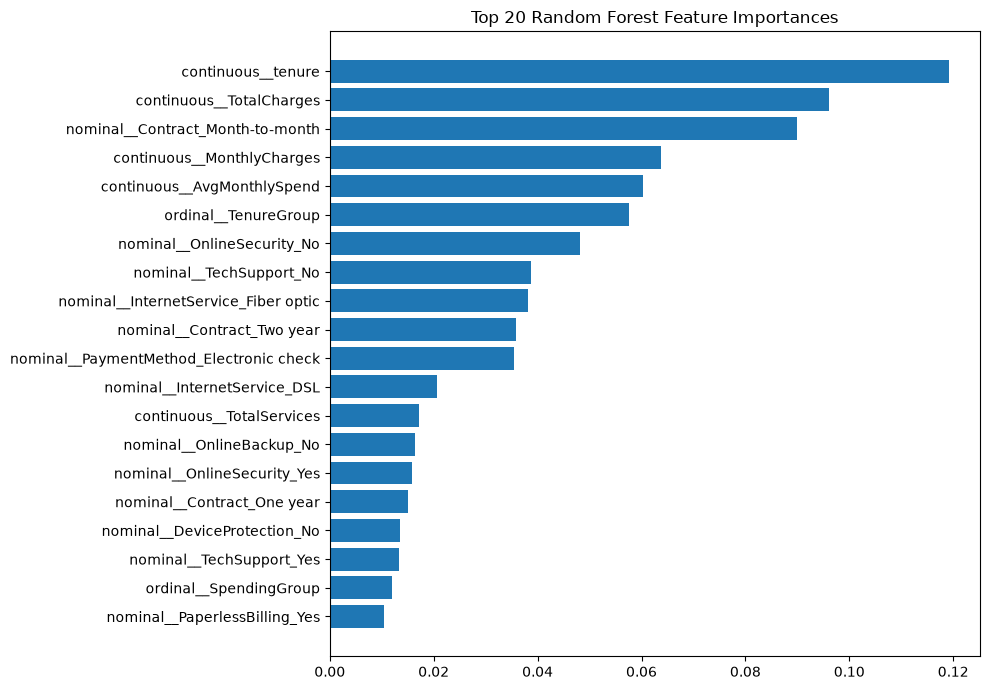

In [30]:
top20 = importance.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()

plt.show()

In [31]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        0.8010,
        0.6442,
        0.5615,
        0.6000,
        0.8350
    ],
    "Decision Tree": [
        0.7839,
        0.5862,
        0.6364,
        0.6103,
        0.8221
    ],
    "Random Forest": test_summary["Score"]
})

comparison

,Metric,Logistic Regression,Decision Tree,Random Forest
0,Accuracy,0.8010,0.7839,0.7932
1,Precision,0.6442,0.5862,0.6436
2,Recall,0.5615,0.6364,0.4973
3,F1,0.6000,0.6103,0.5611
4,ROC-AUC,0.8350,0.8221,0.8340


In [32]:
joblib.dump(
    best_pipeline,
    "../models/random_forest_pipeline.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


# Notebook Summary

## Model Developed

- Random Forest Classifier

## Key Findings

- A tuned Random Forest classifier was developed using GridSearchCV.
- Hyperparameter tuning improved the model's generalization.
- Feature importance analysis identified the most influential variables contributing to customer churn.
- The Random Forest model will be compared with Logistic Regression and Decision Tree to determine the best-performing model.

## Next Steps

The next notebook will develop an XGBoost classifier and compare its performance with the previous models to determine whether gradient boosting provides additional improvements.

## Model Comparison

The Random Forest classifier achieved competitive predictive performance after hyperparameter tuning.

Compared with the previous models:

- Logistic Regression achieved the highest overall Accuracy and ROC-AUC.
- Decision Tree achieved the highest Recall and F1-score.
- Random Forest provided balanced performance but did not outperform the Logistic Regression baseline on this dataset.

These findings demonstrate that increasing model complexity does not necessarily lead to improved predictive performance.

Model selection should be guided by business objectives rather than a single evaluation metric.

For customer retention campaigns, Recall may be prioritized to identify as many at-risk customers as possible.

For overall predictive reliability, Logistic Regression remains the strongest model developed so far.

In [33]:
cv_summary.to_csv(
    "../reports/random_forest_cv.csv",
    index=False
)